# Практическое задание

**Ваша задача:** обучить RNN предсказывать следующий символ в небольшом тексте.

Модель должна работать на уровне символов: получает текущий символ → предсказывает следующий.

Формулы для класса myRNN:
$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$$
$$y_t = W_{hy} \cdot h_t + b_y$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import randn

## 1. Подготовка данных

Цель: каждый символ кодируется как **one-hot вектор**.

In [ ]:
text = "the quick brown fox jumps over the lazy dog"

# ("The quick brown fox jumps over the lazy dog" is an English-language pangram – a sentence that contains all 26 letters of the English alphabet)

In [ ]:
# составляем список уникальных символов и словарь для кодирование

chars = sorted(set(text))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"Размер словаря: {vocab_size}")
print(f"Символы: {chars}")
print(f"Cловарь кодирования букв: {char_to_idx}")

Размер словаря: 27
Символы: [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Cловарь кодирования букв: {' ': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


In [ ]:
def one_hot(idx, size):
    # функция для ohe-hot кодиравания
    vec = np.zeros((size, 1))
    vec[idx] = 1
    return vec

# Проверка: должен напечатать вектор с 1 на нулевой позиции
print(one_hot(0, vocab_size).T)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.]]


In [ ]:
# сформируйте пары (входной вектор, индекс следующего символа)
X = []  # список one-hot векторов
Y = []  # список индексов следующих символов

for i in range(len(text) - 1):
    # Получаем текущий символ и его индекс
    current_char = text[i]
    current_idx = char_to_idx[current_char]
    # Кодируем текущий символ в one‑hot вектор
    one_hot_vector = one_hot(current_idx, vocab_size)
    X.append(one_hot_vector)
    # Получаем индекс следующего символа
    next_char = text[i + 1]
    next_idx = char_to_idx[next_char]
    Y.append(next_idx)


print(f"Количество пар символов: {len(X)}")
print(f"Пример: первый символ '{text[0]}' -> следующий символ '{text[1]}'")

Количество пар символов: 42
Пример: первый символ 't' -> следующий символ 'h'


## 2. Класс myRNN

In [ ]:
class myRNN:

    def __init__(self, input_size, hidden_size, output_size):
        # Инициализируйте веса. Помните, что между весами должно происходить умножение.
        # Вспомните, какие условия накладываются на матрицы, которые умножаются между собой.

        self.Wxh = np.random.randn(hidden_size, input_size) * 0.3
        self.Whh = np.random.randn(hidden_size, hidden_size) * 0.3 # стартовые веса выбираются случайно из нормального распределения и уменьшаются, тк это позволяет сделать обучение более стабильным (видно на логарифмической шкале)
        self.Why = np.random.randn(output_size, hidden_size) * 0.3

        # Это векторы смещения (ставлю нули изначально)
        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((output_size, 1))

    def forward(self, x, h_prev):
        h = np.tanh(self.Wxh @ x + self.Whh @ h_prev + self.bh)
        y =  self.Why @ h + self.by
        return h, y

    def backprop(self, x, h_prev, h, d_y, learn_rate):

        # Градиенты выходного слоя
        d_Why = d_y @ h.T
        d_by  = d_y

        # реализуйте градиент по h через производную tanh
        d_h = self.Why.T @ d_y * (1 - h ** 2)

        d_Wxh = d_h @ x.T
        d_Whh = d_h @ h_prev.T
        d_bh  = d_h

        # обновите оставшиеся веса по аналогии
        self.Why -= learn_rate * d_Why
        self.by  -= learn_rate * d_by
        self.Wxh -= learn_rate * d_Wxh
        self.Whh -= learn_rate * d_Whh
        self.bh  -= learn_rate * d_bh

## 3. Вспомогательные функции

In [ ]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()


## 4. Обучение

In [ ]:
hidden_size = 32
learn_rate  = 0.1
epochs      = 300

model = myRNN(vocab_size, hidden_size, vocab_size)
losses = []

for epoch in range(epochs):
    loss = 0
    h = np.zeros((hidden_size, 1))

    for x, y_true_idx in zip(X, Y):
        h_prev = h

        h, y = model.forward(x, h_prev)

        probs = softmax(y)
        loss += -np.log(probs[y_true_idx][0] + 1e-9)

        d_y = probs.copy()
        d_y[y_true_idx] -= 1
        model.backprop(x, h_prev, h, d_y, learn_rate)

    losses.append(loss)


    if epoch % 30 == 0:
        print(f"Эпоха {epoch:3d}    Loss: {loss:.4f}")

Эпоха   0    Loss: 162.9593
Эпоха  30    Loss: 0.9463
Эпоха  60    Loss: 0.3435
Эпоха  90    Loss: 0.2153
Эпоха 120    Loss: 0.1571
Эпоха 150    Loss: 0.1249
Эпоха 180    Loss: 0.1024
Эпоха 210    Loss: 0.0863
Эпоха 240    Loss: 0.0749
Эпоха 270    Loss: 0.0665


## 5. Визуализация

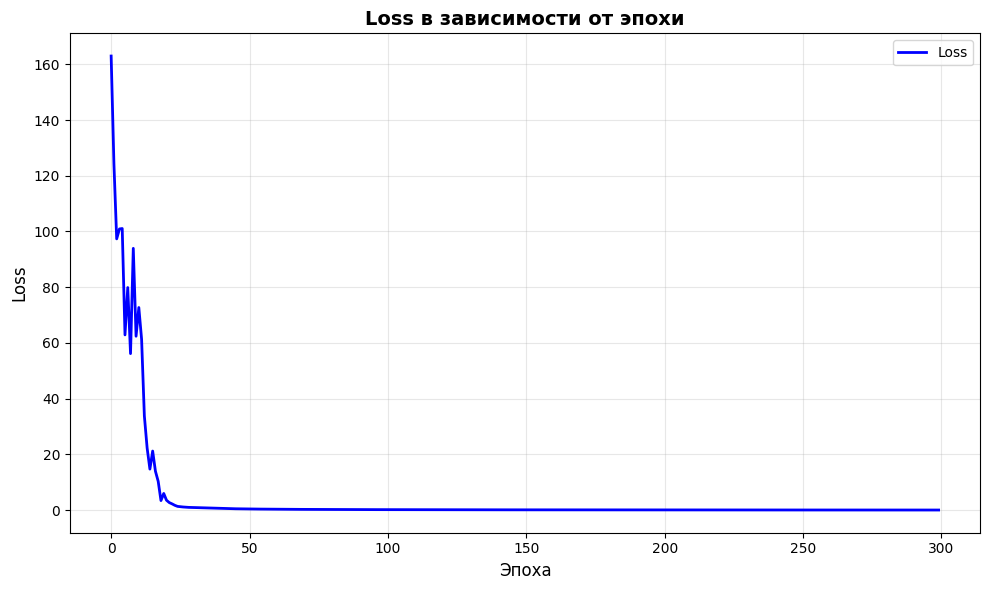

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(losses, label='Loss', color='blue', linewidth=2)
plt.title('Loss в зависимости от эпохи', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

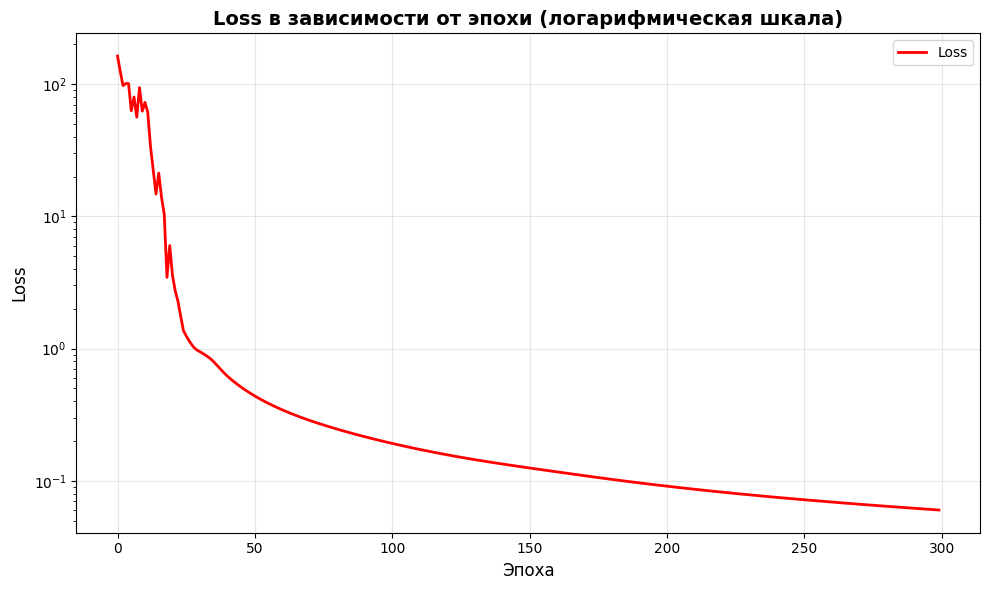

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(losses, label='Loss', color='red', linewidth=2)
plt.title('Loss в зависимости от эпохи (логарифмическая шкала)', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()


## 6. Проверка модели

Раздел для вас, чтобы убедиться, что всё ок

In [ ]:
def generate(model, start_char, length=20):
    # Генерирует строку заданной длины, начиная с start_char
    h      = np.zeros((hidden_size, 1))
    char   = start_char
    result = [char]

    for _ in range(length):
        x = one_hot(char_to_idx[char], vocab_size)
        h, y = model.forward(x, h)
        char = idx_to_char[np.argmax(softmax(y))]
        result.append(char)

    return "".join(result)

# Генерация текста
print("Генерация текста, начиная с разных букв")
for start in ["t", "q", "f", "d"]:
    print(f"  '{start}' -> {generate(model, start)}")

Генерация текста, начиная с разных букв
  't' -> the quick brown fox j
  'q' -> quick ove juips over 
  'f' -> fown jumps ove  the l
  'd' -> dox jumps over the la


#7. Выводы

Код неплохо генерирует простые последовательности символов, которые хоть и не имеют особого смысла, но хотя бы составляют понятные слова друг за другом (возможно конечно модель просто заучила эти слова и не сможет в обобщение, тк текст очень короткий). Но в целом мне кажется архитектура имеет потенциал определять простые последовательности символов (или слов, если научить соответсвенно) если обучить её на гораздо большем объеме данных. Чтобы улучшить модель – можно использовать усложненную архитектуру (GRU, LSTM), добавить регуляризацию, увеличить скрытое состояние (чтобы модель улавливала более длинные закономерности) и количество эпох. Также можно использовать word2vec вместо one-hot кодирования, чтобы учитывать контекст, также было хорошо расширить набор данных